# scRNA-seq Workshop - Day 1 Notebook

This notebook walks through a complete Scanpy workflow on a PBMC dataset:
- data loading (10x)
- normalization + log transform
- QC metrics + filtering strategy
- HVG selection, PCA, neighbors, UMAP
- clustering + marker validation
- doublet detection (Scrublet)
- cell-type annotation + composition
- exploratory DGE (cell-level markers)

**Note:** DGE shown here is intended for *exploratory marker discovery*. For confirmatory condition effects across donors, use replicate-aware pseudobulk models.


## 1. Imports and configuration

In [5]:
import warnings
import scanpy as sc
import pandas as pd
import sctoolkit as sct
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew


## 2. Dataset metadata and loading (10x)

In [6]:

meta = {
    'GSM7077865': 'PBMC resting',
    'GSM7077866': 'PBMC LPS 4 hours',
    'GSM7077867': 'PBMC fresh 1',
    'GSM7077868': 'PBMC fresh  2',
    'GSM7077869': 'PBMC frozen 1',
    'GSM7077870': 'PBMC frozen 2'
    }


In [7]:
# Load a 10x Genomics matrix and assign it to `adata`.

GSM7077865 = sc.read_10x_mtx('../../GSE226488/GSM7077865_D1_filtered_feature_bc_matrix/')
adata = GSM7077865

## 3. Robust pre-processing roadmap

This notebook is organized to follow the slide-deck *Robust Pre-processing* workflow:
**QC → Normalization → Feature selection → Dimensionality reduction → Neighbors graph → Clustering → Annotation → DGE**.

(See the workflow overview in the slide deck.)


## 4. Quality control (QC)

Filter low-quality cells/genes using:
1. **Mitochondrial reads**
2. **Read counts per cell**
3. **Genes detected per cell**
4. **Doublets**


In [8]:
# Basic setup: unique names + store raw counts in a dedicated layer for QC/doublets
adata.var_names_make_unique()
adata.obs_names_make_unique()
adata.obs["batch"] = 'GSM7077865'

# Preserve raw UMIs (counts) in a layer so we can safely modify `adata.X` later
adata.layers['UMIs'] = adata.X.copy()


... storing 'batch' as categorical
... storing 'qc_issue' as categorical
... storing 'feature_types' as categorical


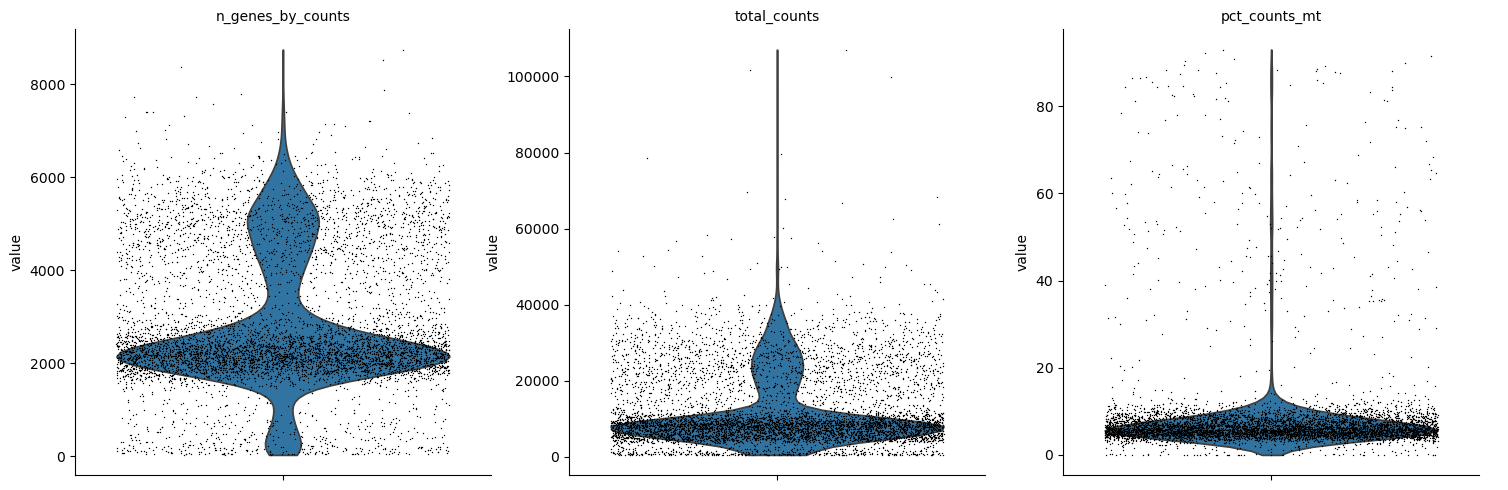

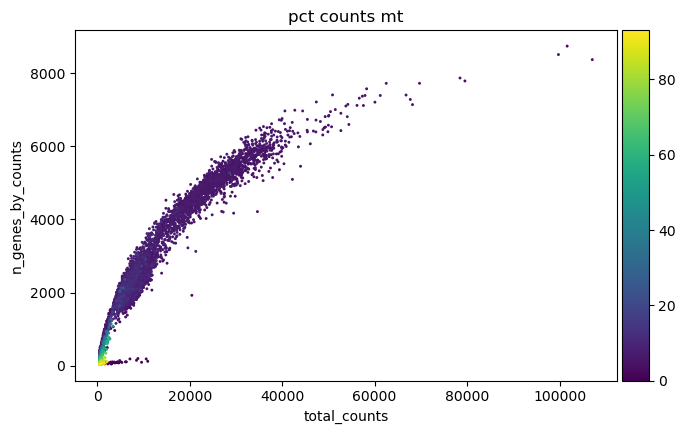

In [9]:
# Compute QC metrics (mitochondrial fraction, total counts, genes detected) and define QC thresholds.

adata.var["mt"] = adata.var_names.str.match(r"^(MT|mt)-")

sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True, layer='UMIs'
)

# 3. Define Thresholds 
counts_quantile_low = 0.05
counts_quantile_high = 0.95
mt_pct_quantile_high = 0.95

# 4. Calculate Quantile Values
low = np.quantile(adata.obs.total_counts, counts_quantile_low)
high = np.quantile(adata.obs.total_counts, counts_quantile_high)
mt_high = np.quantile(adata.obs.pct_counts_mt, mt_pct_quantile_high)

adata.obs["qc_issue"] = "OK"

is_low = adata.obs.total_counts < low
is_high = adata.obs.total_counts > high
is_high_mt = adata.obs.pct_counts_mt > mt_high

adata.obs.loc[is_low, "qc_issue"] = "low_counts"
adata.obs.loc[is_high, "qc_issue"] = "high_counts"
adata.obs.loc[is_high_mt, "qc_issue"] = "high_mt"

adata.obs['c_g_ratio'] = adata.obs.total_counts / adata.obs.n_genes_by_counts
is_high_rt = adata.obs.c_g_ratio >= 20 
adata.obs.loc[is_high_rt, "qc_issue"] = "high_rt"


sc.pl.violin(adata,['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], 
             jitter=0.4, 
             multi_panel=True)
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', color='pct_counts_mt')

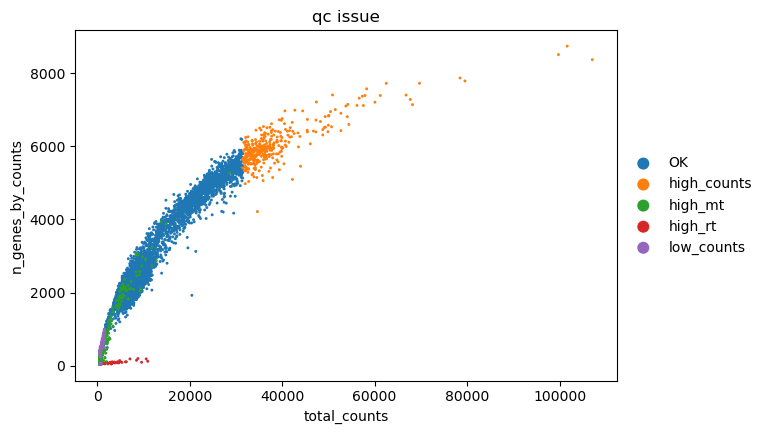

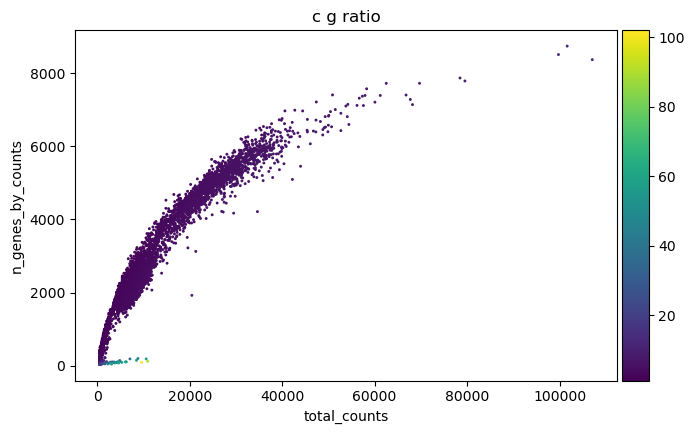

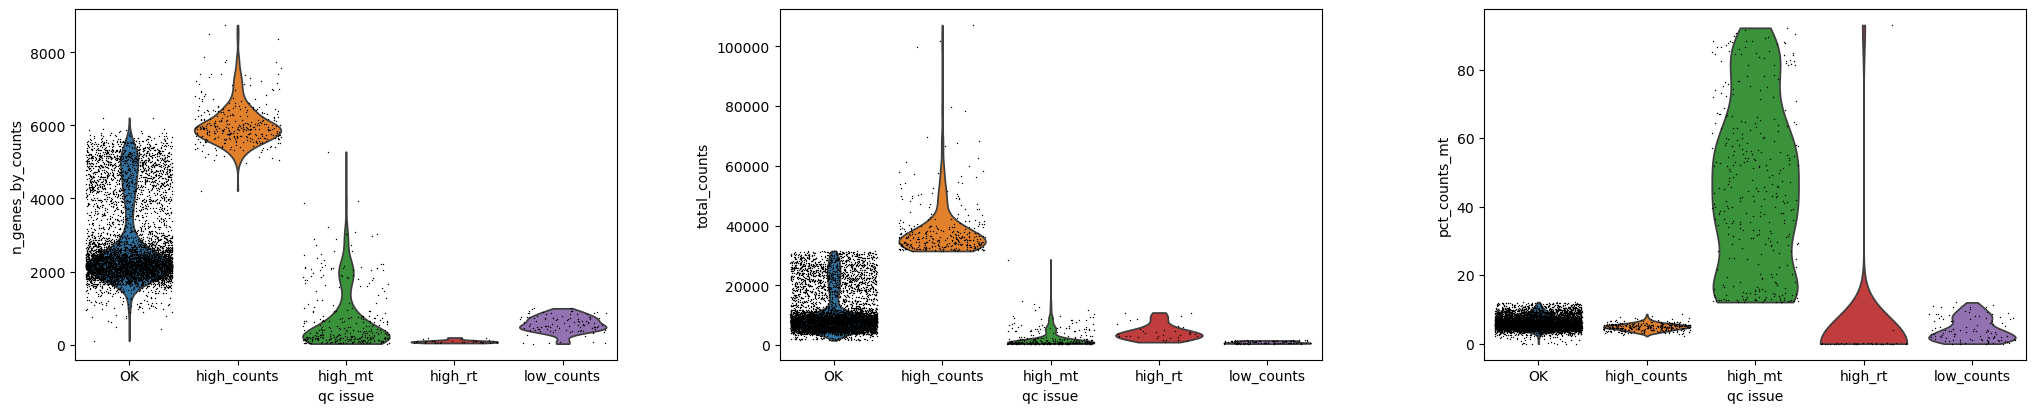

In [10]:
# QC diagnostic plots (scatter + violins).

sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', color='qc_issue')
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', color='c_g_ratio')

sc.pl.violin(adata,['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], 
             jitter=0.4, 
             multi_panel=True, groupby='qc_issue')



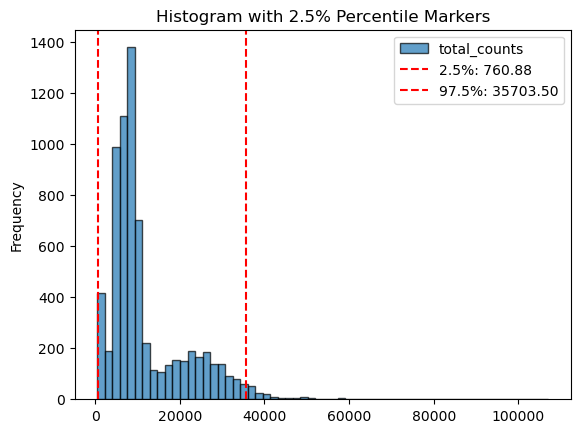

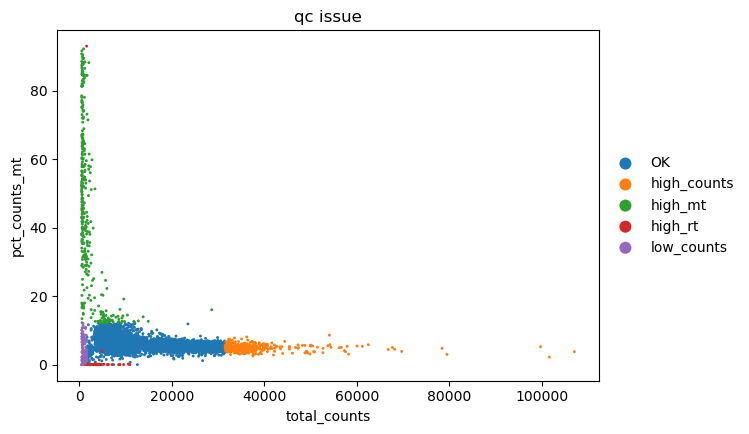

In [11]:

ax = adata.obs.total_counts.plot(kind='hist', bins=60, edgecolor='black', alpha=0.7)

lower_bound = adata.obs.total_counts.quantile(0.025)
upper_bound = adata.obs.total_counts.quantile(0.975)
plt.axvline(lower_bound, color='red', linestyle='--', label=f'2.5%: {lower_bound:.2f}')
plt.axvline(upper_bound, color='red', linestyle='--', label=f'97.5%: {upper_bound:.2f}')

# Add labels and legend
plt.title('Histogram with 2.5% Percentile Markers')
plt.legend()
plt.show()


sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt', color='qc_issue')


**Note on doublets:** we'll run Scrublet after an initial embedding/clustering, then iterate filtering/reclustering.


## 5. Normalization and log transform

Adjust for count depth (library size), then apply `log1p` so the data are more model-friendly.


In [12]:
# Normalize total counts per cell, then log-transform.
# Keep intermediate layers for teaching/debugging.

adata.X = adata.layers['UMIs'].copy()
sc.pp.normalize_total(adata)
adata.layers['normed'] = adata.X.copy()
sc.pp.log1p(adata)
adata.layers['l1p'] = adata.X.copy()


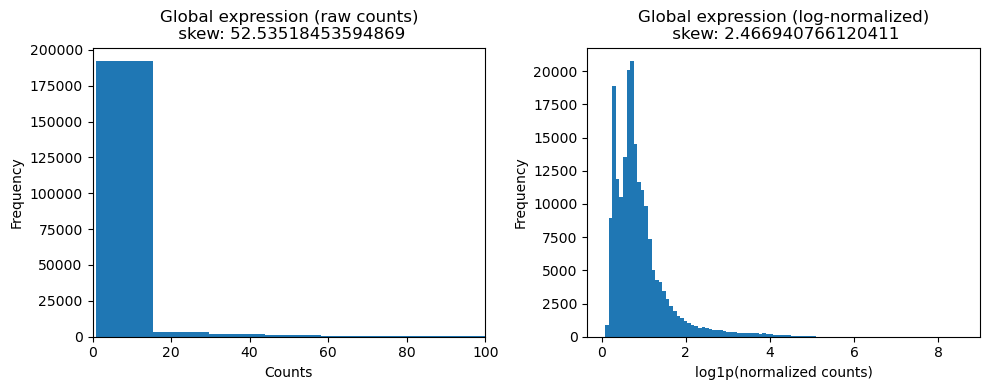

In [13]:
# Quantify global expression skewness before vs after log-normalization; visualize histograms.

raw = np.asarray(adata.layers["UMIs"].todense()).flatten()
lognorm = np.asarray(adata.X.todense()).flatten()

raw_nz = raw[raw > 0]
log_nz = lognorm[lognorm > 0]
skew_raw = skew(raw_nz)
skew_log = skew(log_nz)

n = 200_000
if raw_nz.size > n:
    idx = np.random.choice(raw_nz.size, n, replace=False)
    raw_nz = raw_nz[idx]
    log_nz = log_nz[idx]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Raw counts
axes[0].hist(raw_nz, bins=100)
axes[0].set_xlim(0, 100)
axes[0].set_title(f"Global expression (raw counts)\n skew: {skew_raw}")
axes[0].set_xlabel("Counts")
axes[0].set_ylabel("Frequency")

# Log-normalized
axes[1].hist(log_nz, bins=100)
axes[1].set_title(f"Global expression (log-normalized)\n skew: {skew_log}")
axes[1].set_xlabel("log1p(normalized counts)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 6. Feature selection (highly-variable genes)

Select informative genes using the mean–variance relationship (HVGs).


/Users/gas361/anaconda3/envs/sctoolkit/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding


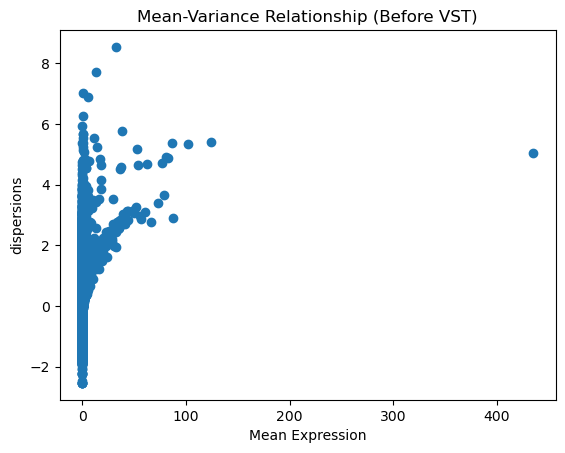

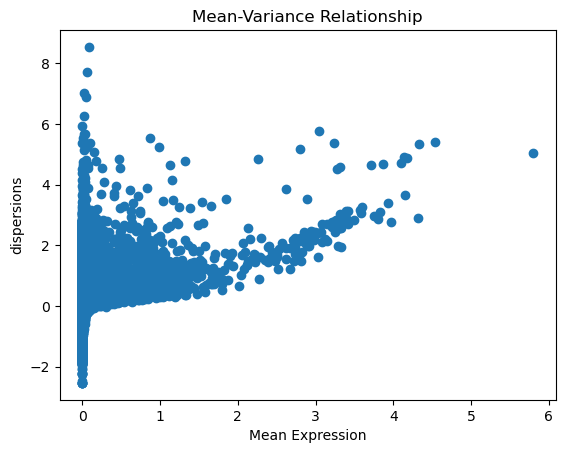

In [14]:
# Select highly-variable genes (HVGs) and visualize mean–variance relationship.

sc.pp.highly_variable_genes(adata, n_top_genes = 2000, layer='l1p')

sc.pp.calculate_qc_metrics(adata, inplace=True, layer='normed',)
plt.scatter(adata.var['mean_counts'], adata.var['dispersions'])
plt.xlabel('Mean Expression')
plt.ylabel('dispersions')
plt.title('Mean-Variance Relationship (Before VST)')
plt.show()
# adata
# var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts',
# 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions',
# 'dispersions_norm', 'mean', 'std', 'log1p_mean_counts', 'log1p_total_counts'
# sc.pl.highly_variable_genes(adata)
sc.pp.calculate_qc_metrics(adata, inplace=True, layer='l1p')
plt.scatter(adata.var['mean_counts'], adata.var['dispersions'])
plt.xlabel('Mean Expression')
plt.ylabel('dispersions')
plt.title('Mean-Variance Relationship')
plt.show()


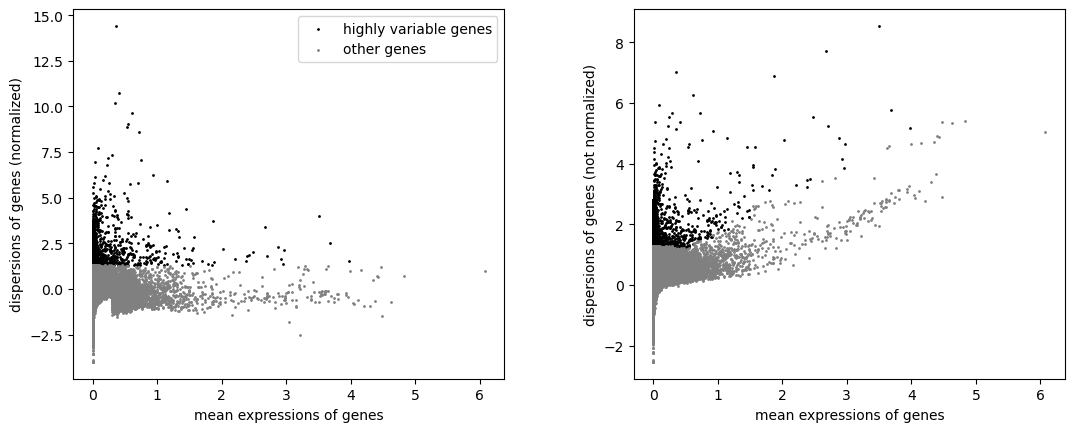

In [15]:
# Plot HVGs (Scanpy built-in).

sc.pl.highly_variable_genes(adata)

## 7. Dimensionality reduction, neighbors graph, and clustering

**PCA → kNN graph → UMAP → Leiden**.


/Users/gas361/anaconda3/envs/sctoolkit/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


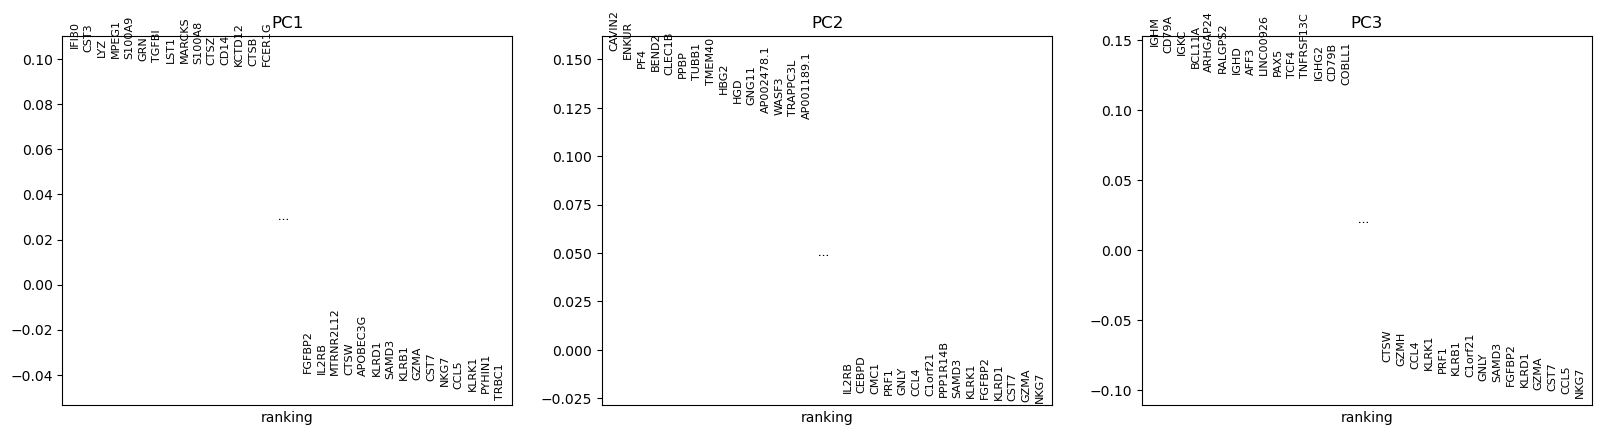

In [16]:
# Scale, run PCA, and inspect PCA loadings.

sc.pp.scale(adata)
sc.tl.pca(adata)
sc.pl.pca_loadings(adata, components=[1, 2, 3], include_lowest=True)

In [17]:
# Compute neighbors, UMAP embedding, and Leiden clustering.

sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution = .4)

/Users/gas361/anaconda3/envs/sctoolkit/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/c3/7p4q46xs3yv4_jgf7k4qf_3w0000gn/T/ipykernel_18650/907118003.py:5: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution = .4)


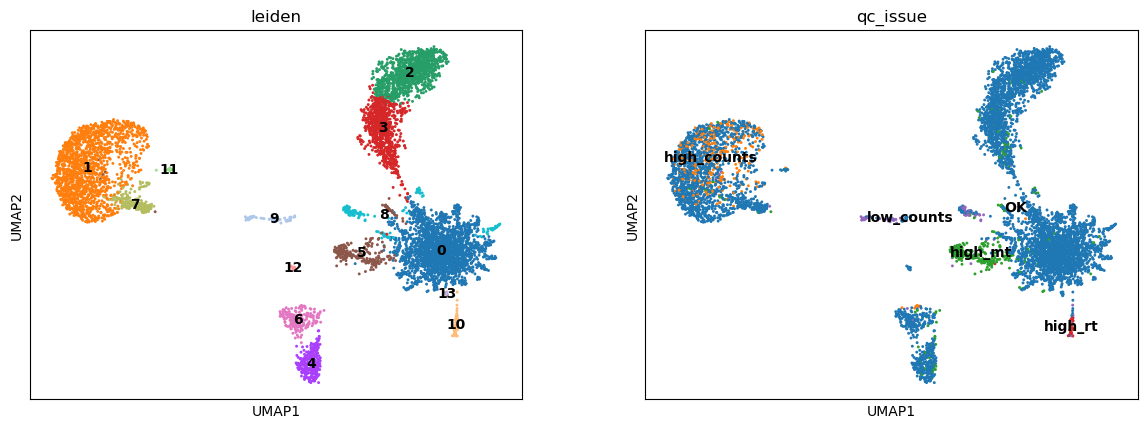

/Users/gas361/Desktop/CGSB_WORKSHOP/das2_sc_toolkit/src/sctoolkit/helpers.py:432: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  composition = df.groupby(groupby + split_by).count().reset_index()


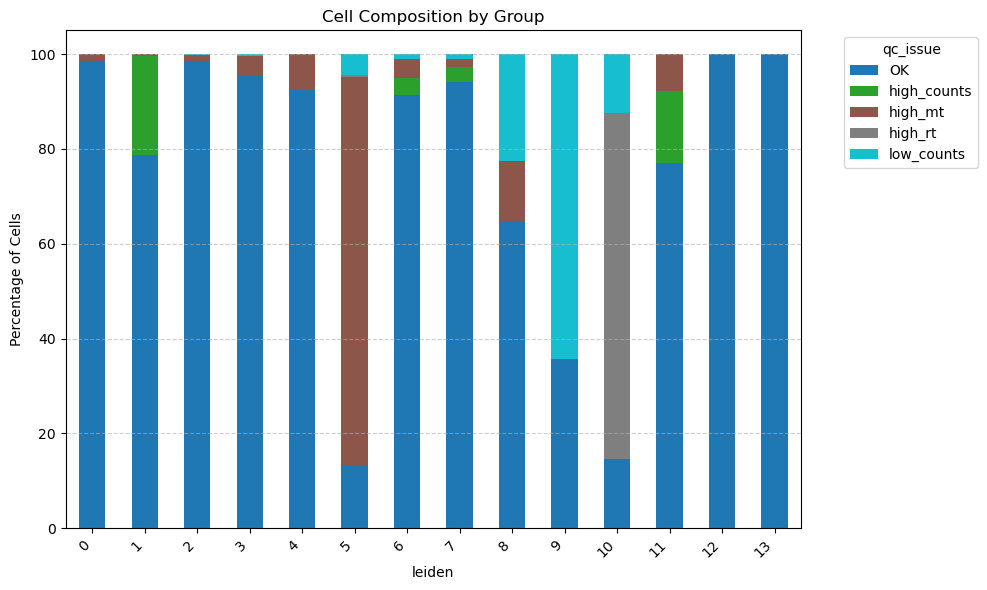

In [18]:
# Visualize clusters and QC issues; inspect cluster composition by QC flags.

sc.pl.umap(adata, color=['leiden', 'qc_issue'], legend_loc='on data')
sct.plot_composition(adata,'leiden','qc_issue', colormap='tab10')

## 7. Doublet detection (Scrublet outputs)

In [19]:
adata.X = adata.layers['UMIs'].copy()
sc.pp.scrublet(adata,)

/Users/gas361/anaconda3/envs/sctoolkit/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding


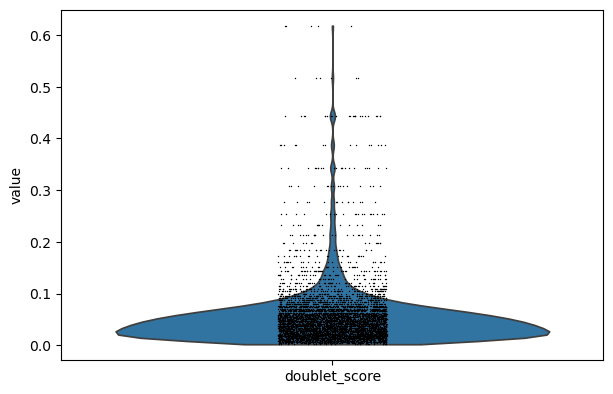

/var/folders/c3/7p4q46xs3yv4_jgf7k4qf_3w0000gn/T/ipykernel_18650/1759021287.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


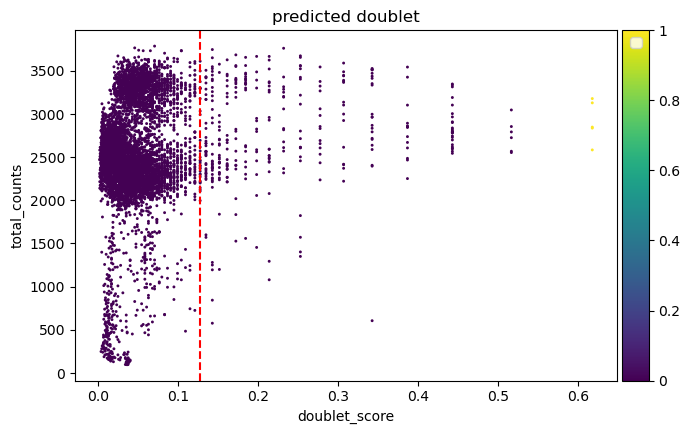

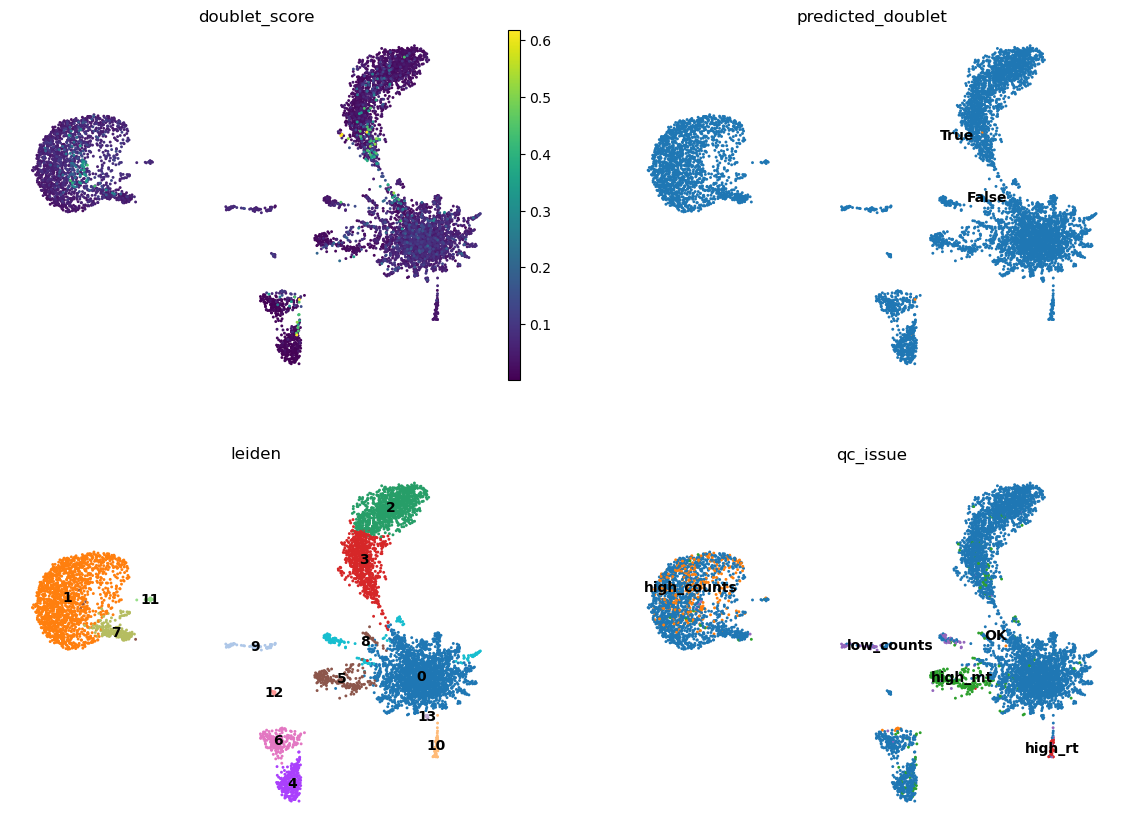

/Users/gas361/Desktop/CGSB_WORKSHOP/das2_sc_toolkit/src/sctoolkit/helpers.py:432: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  composition = df.groupby(groupby + split_by).count().reset_index()


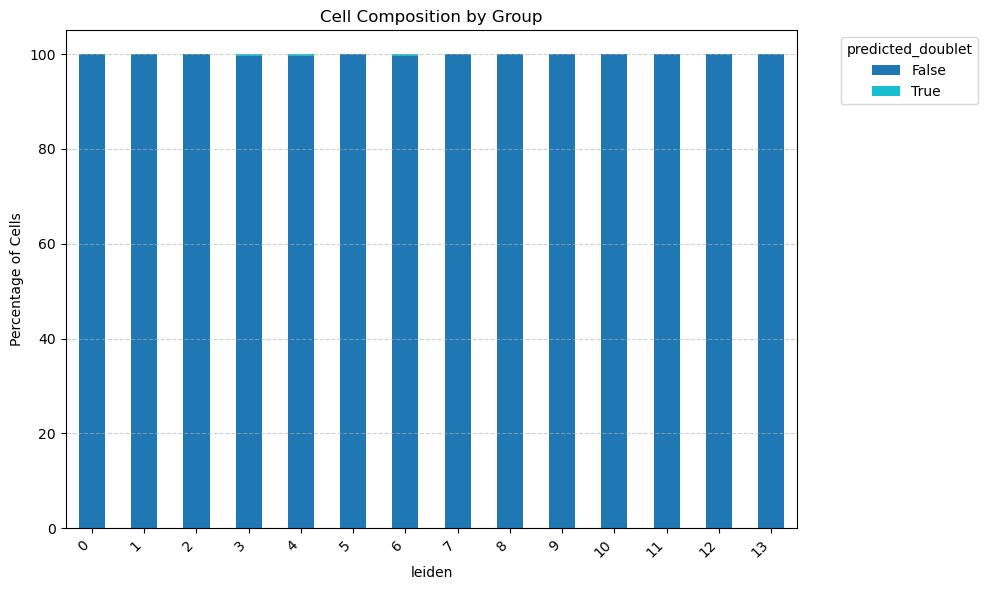

In [20]:
# Inspect doublet scores and predicted doublets on UMAP.

sc.pl.violin(adata, 'doublet_score')
limit = adata.obs.doublet_score.quantile(0.95)

# 2. Generate the plot (note: show=False is key)
ax = sc.pl.scatter(
    adata, 
    x='doublet_score', 
    y='total_counts', 
    color='predicted_doublet', 
    show=False
)

# 3. Add the vertical line to the captured axes
ax.axvline(limit, color='red', linestyle='--', label=f'95th Percentile: {limit:.2f}')

# 4. Refresh the legend and show
plt.legend()
plt.show()

sc.pl.umap(adata, color=['doublet_score', 'predicted_doublet',
                         'leiden','qc_issue'], ncols=2, frameon=False, legend_loc='on data')
sct.plot_composition(adata,'leiden','predicted_doublet', colormap='tab10')

## 8. Marker validation with dotplots and iterative reclustering

In [21]:
# Define canonical marker genes for PBMC cell types.

marker_map = {}

marker_map['Naive CD4+ T'] = ['IL7R', 'CCR7', 'LTB', 'MALAT1']
marker_map['Memory CD4+ T'] = ['IL7R', 'S100A4', 'IL32', 'LTB']

marker_map['CD8+ T'] = ['CD3D', 'CD3E', 'CD8A', 'CD8B', 'LTB']
marker_map['Cytotoxic T / Effector'] = ['NKG7', 'GZMB', 'PRF1', 'GNLY']

marker_map['NK'] = ['NKG7', 'GNLY', 'KLRD1', 'FCGR3A', 'PRF1']

marker_map['CD14+ Mono'] = ['LYZ', 'S100A8', 'S100A9', 'LGALS3', 'CTSS', 'CD14']
marker_map['FCGR3A+ Mono'] = ['FCGR3A', 'MS4A7', 'LST1', 'LGALS3', 'IFITM3']

marker_map['B'] = ['MS4A1', 'CD79A', 'CD74', 'HLA-DRA']
marker_map['DC (cDC)'] = ['FCER1A', 'CLEC10A', 'CD74', 'HLA-DRA']
marker_map['pDC'] = ['GZMB', 'IRF7', 'IL3RA', 'SERPINF1']
marker_map['Platelet'] = ['PPBP', 'PF4']

In [22]:
# Compute exploratory markers per Leiden cluster (cell-level Wilcoxon).

sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    method="wilcoxon", layer='l1p'
)


categories: 0, 1, 2, etc.
var_group_labels: Naive CD4+ T, Memory CD4+ T, CD8+ T, etc.


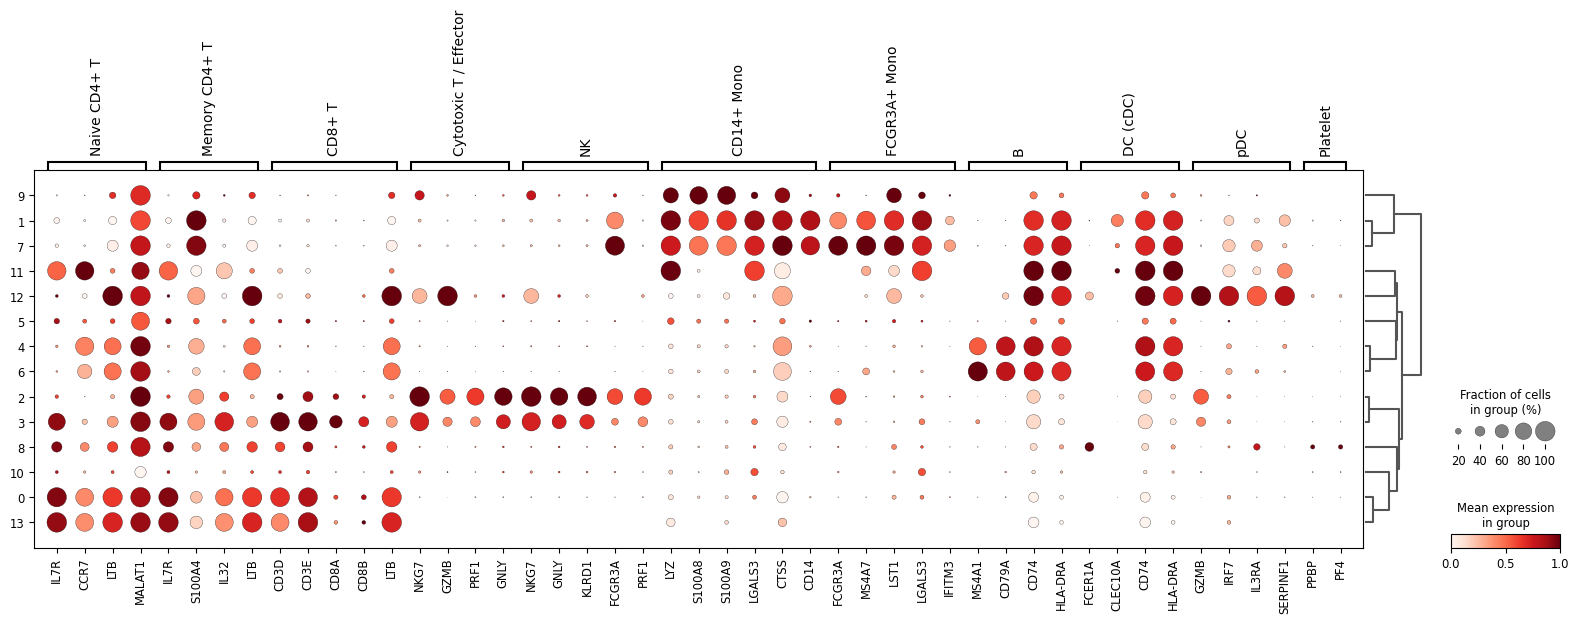

2026-02-24 02:04:48,883 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-24 02:04:48,890 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-24 02:04:48,893 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-24 02:04:49,017 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-24 02:04:49,032 - INFO - Using categorical units to plot a list of strings that are all parsable as 

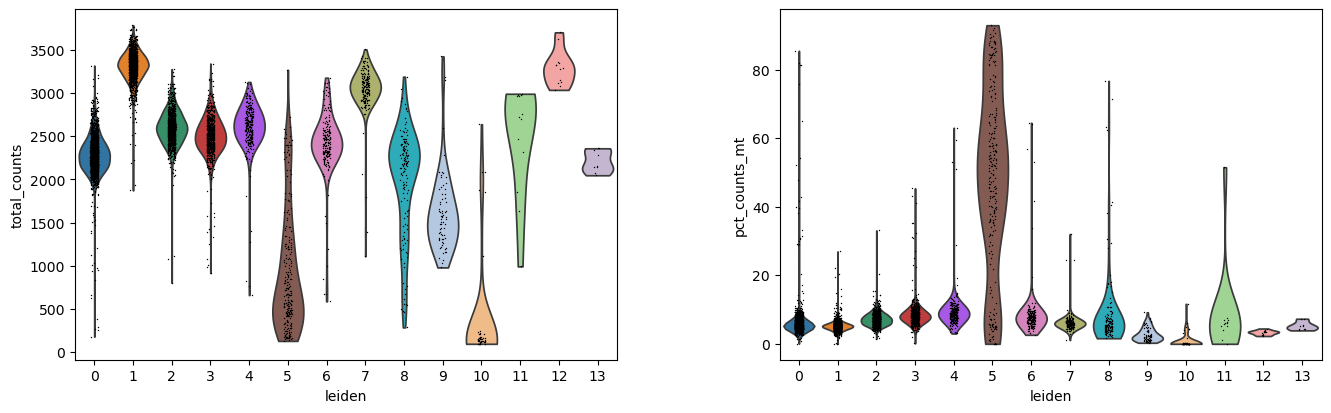

In [23]:
# Dotplot marker validation + per-cluster QC violin diagnostics.

sc.tl.dendrogram(adata,'leiden')
sc.pl.dotplot(
    adata,
    var_names=marker_map,
    groupby="leiden",
    layer="l1p",
    standard_scale='var',
    dendrogram=True,
    mean_only_expressed=True
)
sc.pl.violin(adata, ['total_counts', 'pct_counts_mt'], groupby='leiden')

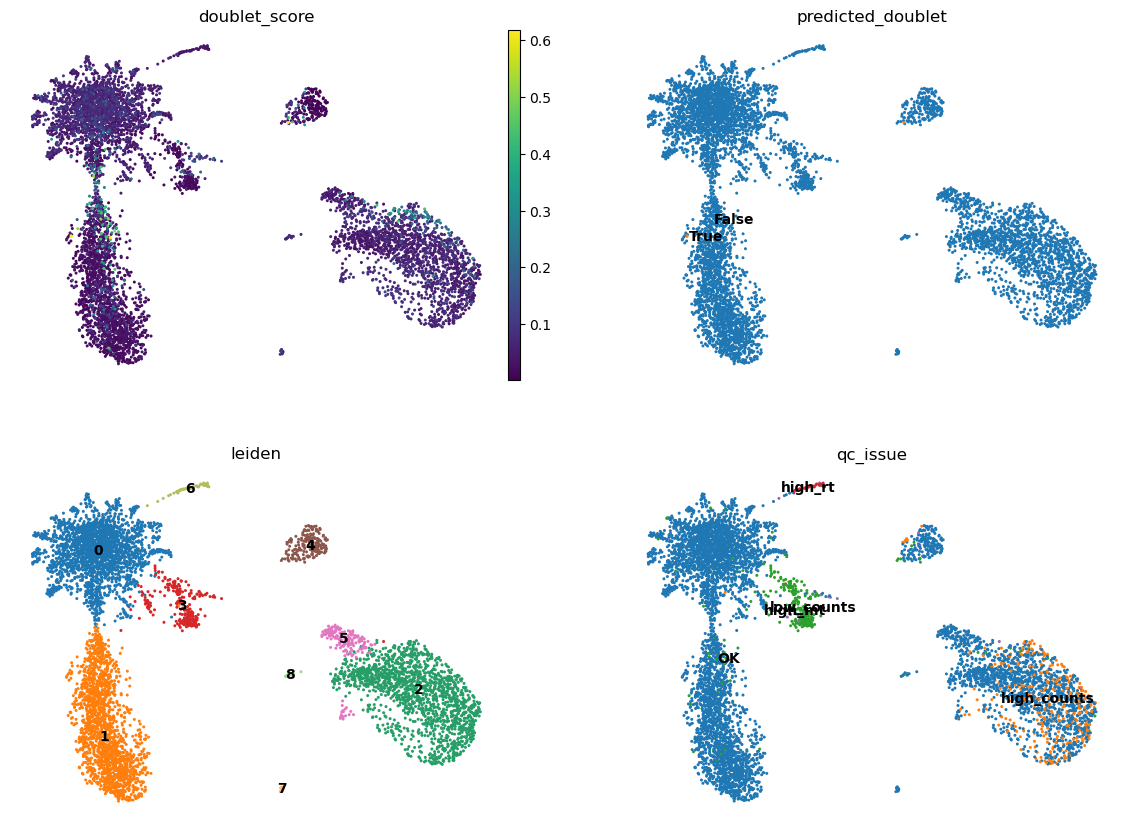

In [24]:
# Manually remove selected clusters and recluster (exploratory triage).

adata = adata[~adata.obs['leiden'].isin(['4','8','9'])].copy()
sc.pp.neighbors(adata)
sc.tl.leiden(adata, resolution=0.3)
sc.tl.umap(adata)
sc.pl.umap(adata, color=['doublet_score', 'predicted_doublet',
                         'leiden','qc_issue'], ncols=2, frameon=False, 
           legend_loc='on data')


In [25]:
# Remove top 5% by doublet score and recluster; recompute dendrogram.

counts_quantile_high = 0.95
dbl = np.quantile(adata.obs.doublet_score, counts_quantile_high)
adata = adata[adata.obs.doublet_score < dbl].copy()

sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.3)
sc.tl.dendrogram(adata,'leiden')


categories: 0, 1, 2, etc.
var_group_labels: Naive CD4+ T, Memory CD4+ T, CD8+ T, etc.


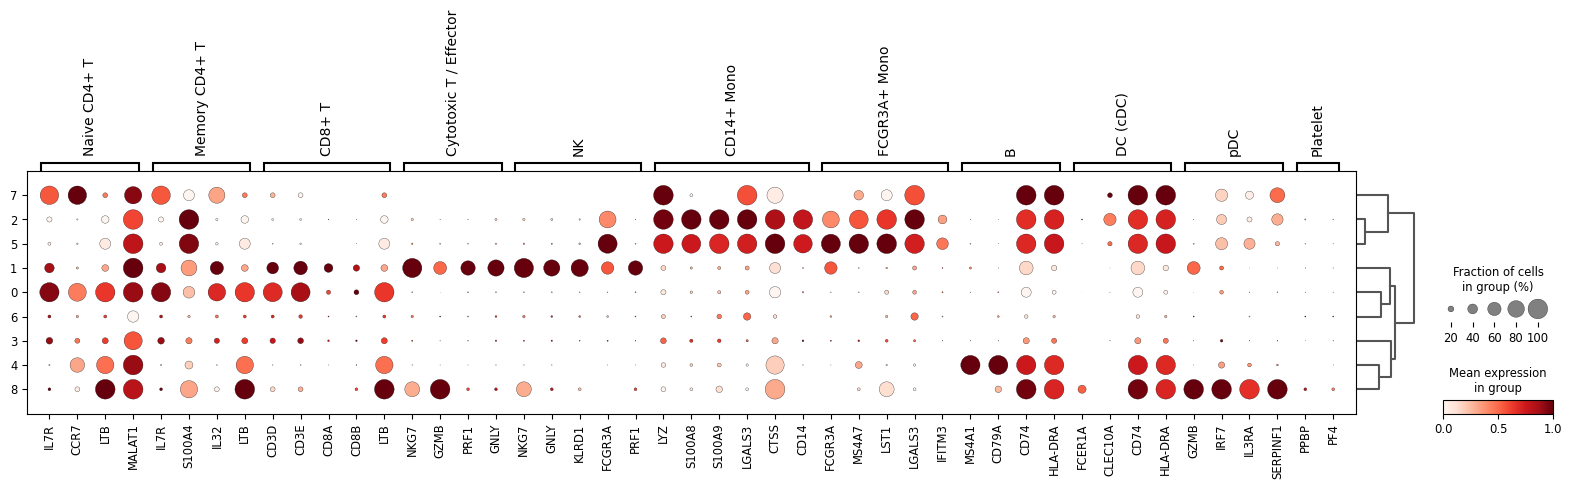

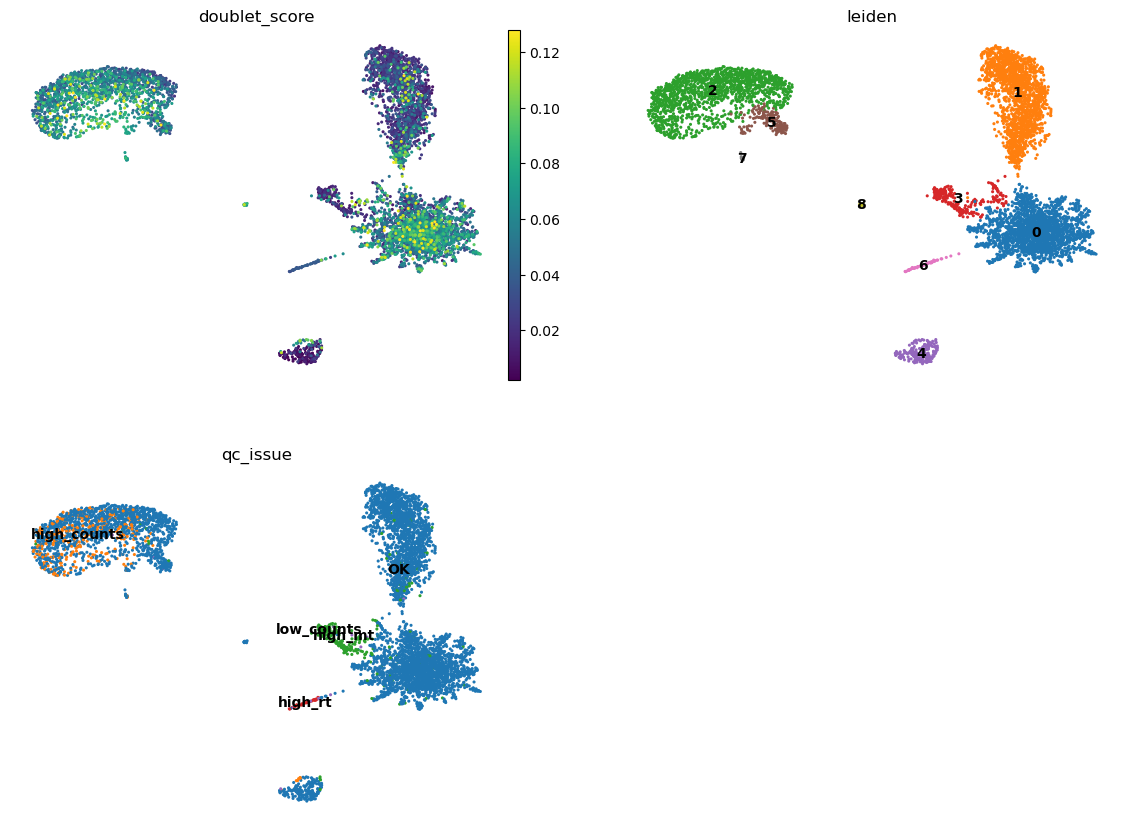

In [26]:
# Re-check marker dotplot and QC/embedding after doublet filtering.

sc.pl.dotplot(
    adata,
    var_names=marker_map,
    groupby="leiden",
    layer="l1p",
    standard_scale='var',
    dendrogram=True,
    mean_only_expressed=True
)
sc.pl.umap(adata, color=['doublet_score',
                         'leiden','qc_issue'], ncols=2, frameon=False, 
           legend_loc='on data')


## 9. Keep only QC-passing cells and finalize clustering

categories: 0, 1, 2, etc.
var_group_labels: Naive CD4+ T, Memory CD4+ T, CD8+ T, etc.


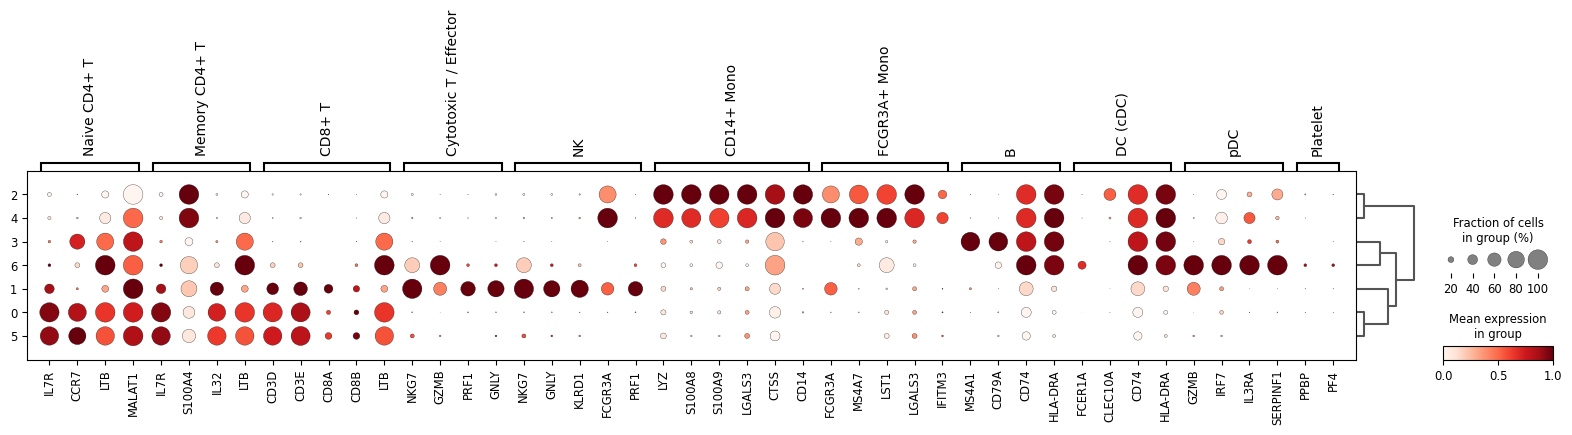

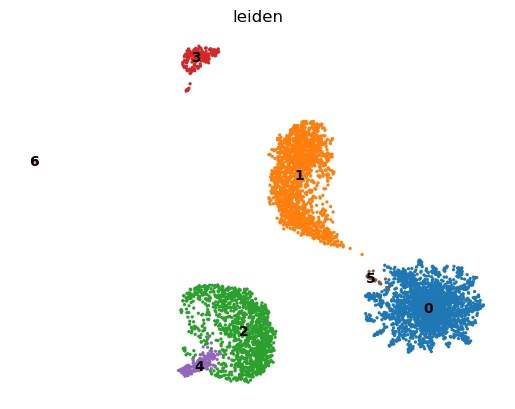

In [27]:
# Subset to QC-passing cells only; recluster; validate markers.

adata_ok = adata[adata.obs.qc_issue.eq('OK')].copy()
sc.pp.neighbors(adata_ok)
sc.tl.umap(adata_ok)
sc.tl.leiden(adata_ok, resolution=0.3)
sc.tl.dendrogram(adata_ok,'leiden')

sc.pl.dotplot(
    adata_ok,
    var_names=marker_map,
    groupby="leiden",
    layer="l1p",
    standard_scale='var',
    dendrogram=True,
    mean_only_expressed=True
)
sc.pl.umap(adata_ok, color=['leiden'], ncols=2, frameon=False,legend_loc='on data')


categories: 0, 1, 2, etc.
var_group_labels: Naive CD4+ T, Memory CD4+ T, CD8+ T, etc.


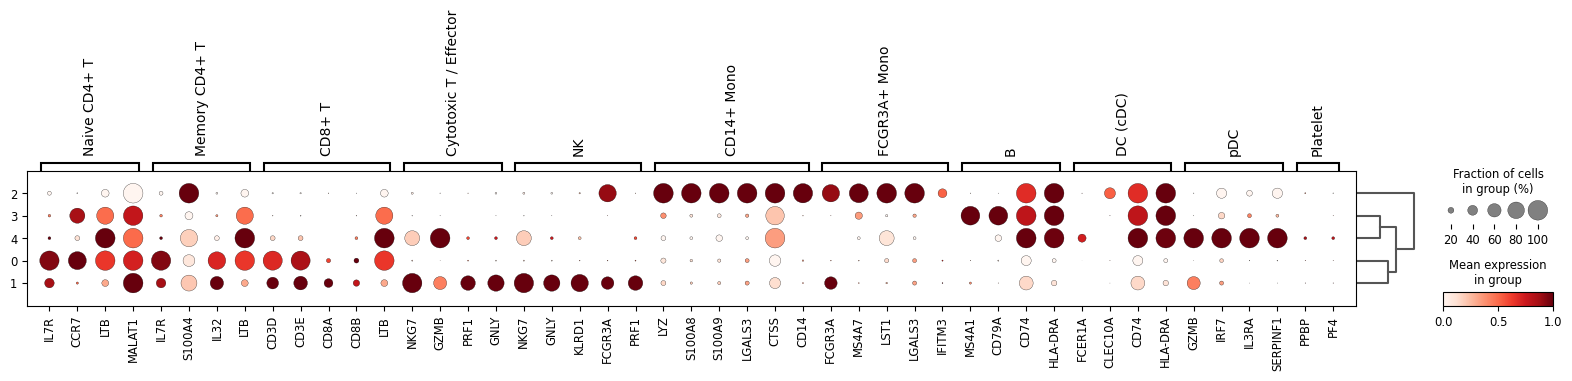

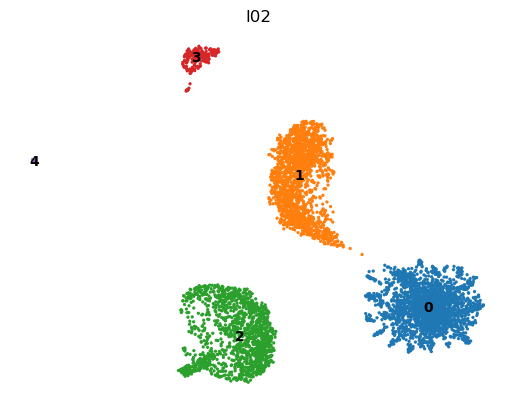

In [28]:
# Try a lower clustering resolution and re-validate marker patterns.

sc.tl.leiden(adata_ok, resolution=0.2, key_added='l02')
sc.tl.dendrogram(adata_ok,'l02')

sc.pl.dotplot(
    adata_ok,
    var_names=marker_map,
    groupby="l02",
    layer="l1p",
    standard_scale='var',
    dendrogram=True,
    mean_only_expressed=True
)
sc.pl.umap(adata_ok, color=['l02'], ncols=2, frameon=False,legend_loc='on data')


## 10. Cell-type annotation from canonical markers

cell_type
Naive CD4         2208
Classical Mono    1183
Cytotoxic T        876
Memory CD4         778
B                  187
FCGR3A Mono        171
pDC                 13
Name: count, dtype: int64


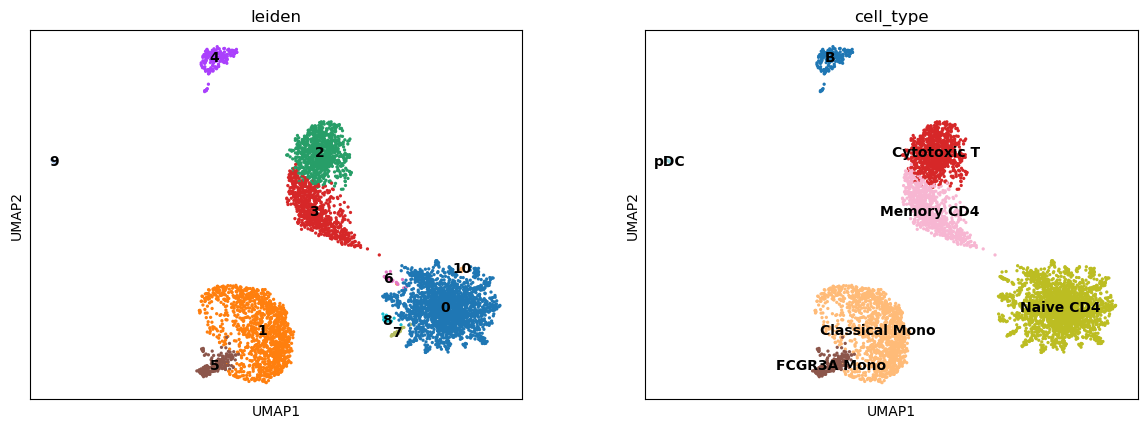

In [ ]:
sc.tl.leiden(adata_ok, resolution=0.4, key_added='leiden')
sc.tl.dendrogram(adata_ok,'leiden')
cluster_key = 'leiden'
# Map clusters to cell-type labels; store as `adata_ok.obs['cell_type']`.
genes = [g for gs in marker_map.values() for g in gs]
genes = [g for g in genes if g in adata_ok.var_names]
expr = sc.get.obs_df(adata_ok, keys=genes, layer='l1p')

# cluster-level mean & % expressed
clusters = adata_ok.obs[cluster_key].astype(str)
cluster_mean = expr.groupby(clusters).mean()
cluster_pct  = expr.gt(0).groupby(clusters).mean()

# aggregate per cell-type (mean across markers), z-score across cell-types, combine
cell_types = list(marker_map.keys())
mean_scores = pd.DataFrame({ct: cluster_mean[[g for g in marker_map[ct] if g in cluster_mean.columns]].mean(axis=1) for ct in cell_types})
pct_scores  = pd.DataFrame({ct: cluster_pct[[g for g in marker_map[ct] if g in cluster_pct.columns]].mean(axis=1)  for ct in cell_types})

z_mean = mean_scores.sub(mean_scores.mean(axis=1), axis=0).div(mean_scores.std(axis=1).replace(0,1), axis=0)
z_pct  = pct_scores.sub(pct_scores.mean(axis=1), axis=0).div(pct_scores.std(axis=1).replace(0,1), axis=0)

assigned = (0.6 * z_mean + 0.4 * z_pct).idxmax(axis=1)

broad_map = {
    "T": ["TRAC","CD3D","CD3E"],
    "NK": ["NKG7","GNLY","KLRD1"],
    "Mono": ["LYZ","S100A8","S100A9","LST1"],
    "B": ["MS4A1","CD79A","CD74"],
    "DC": ["FCER1A","IL3RA","HLA-DRA"],
    "Platelet": ["PPBP","PF4"]
}

sub_map = {
    "Naive CD4": ["IL7R","CCR7","LTB"],
    "Memory CD4": ["IL7R","S100A4","IL32"],
    "CD8": ["CD8A","CD8B","CCL5","GZMK"],
    "Cytotoxic T": ["TRAC","NKG7","GNLY","GZMB","PRF1"],
    "Classical Mono": ["CD14","S100A8","S100A9"],
    "FCGR3A Mono": ["FCGR3A","MS4A7","LST1"],
    "cDC": ["FCER1A","CLEC10A","CD74"],
    "pDC": ["IL3RA","IRF7","GZMB"],
}

def agg_scores(gmap):
    return pd.DataFrame({
        k: (cluster_mean[[g for g in v if g in cluster_mean.columns]].mean(1) +
            cluster_pct[[g for g in v if g in cluster_pct.columns]].mean(1))
        for k,v in gmap.items()
    })

broad = agg_scores(broad_map).idxmax(1)     # cluster -> broad lineage
sub   = agg_scores(sub_map).idxmax(1)       # cluster -> subtype candidate

final = []
for cl in broad.index:
    b = broad.loc[cl]
    s = sub.loc[cl]
    if (b=="T" and s in ["Naive CD4","Memory CD4","CD8","Cytotoxic T"]) or \
       (b=="NK" and s in ["Cytotoxic T"]) or \
       (b=="Mono" and s in ["Classical Mono","FCGR3A Mono"]) or \
       (b=="DC" and s in ["cDC","pDC"]) or \
       (b=="B" and s in ["B"]) or \
       (b=="Platelet" and s in ["Platelet"]):
        final.append(s)
    else:
        final.append(b)

final = pd.Series(final, index=broad.index)
adata_ok.obs["cell_type"] = adata_ok.obs["leiden"].astype(str).map(final).astype("category")

print(adata_ok.obs['cell_type'].value_counts())
sc.pl.umap(adata_ok, color=[cluster_key, 'cell_type'], legend_loc='on data')


categories: B, Classical Mono, Cytotoxic T, etc.
var_group_labels: Naive CD4+ T, Memory CD4+ T, CD8+ T, etc.


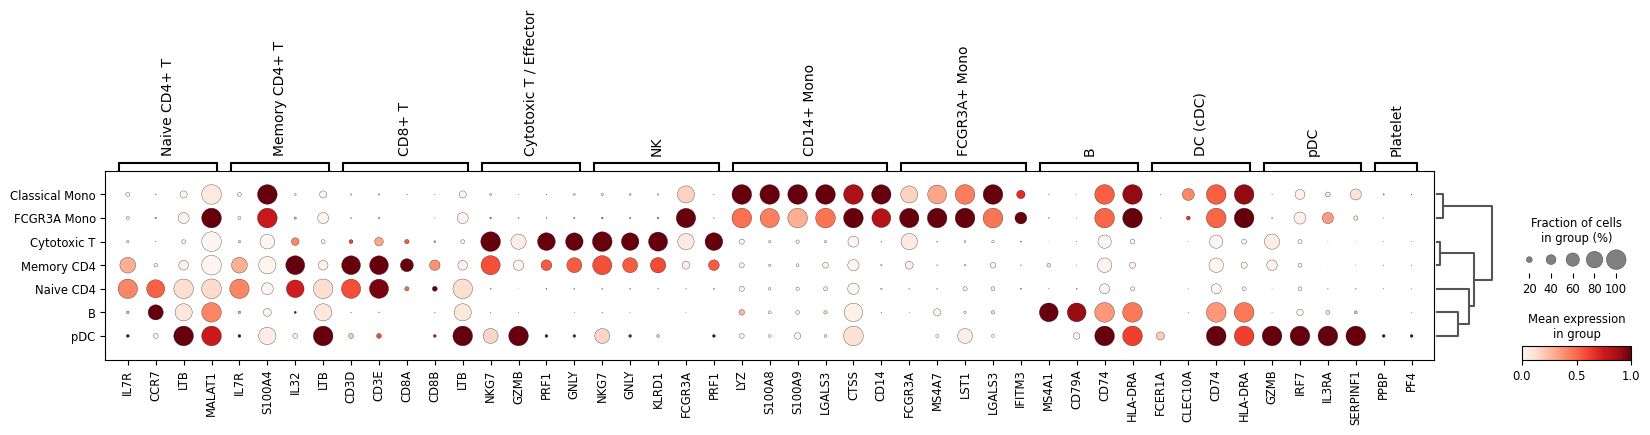

In [ ]:

sc.tl.dendrogram(adata_ok,groupby="cell_type")

sc.pl.dotplot(
    adata_ok,
    var_names=marker_map,
    groupby="cell_type",
    mean_only_expressed=True,
    standard_scale="var",
    dendrogram=True,
)

## 11. Composition plot (counts + proportions)

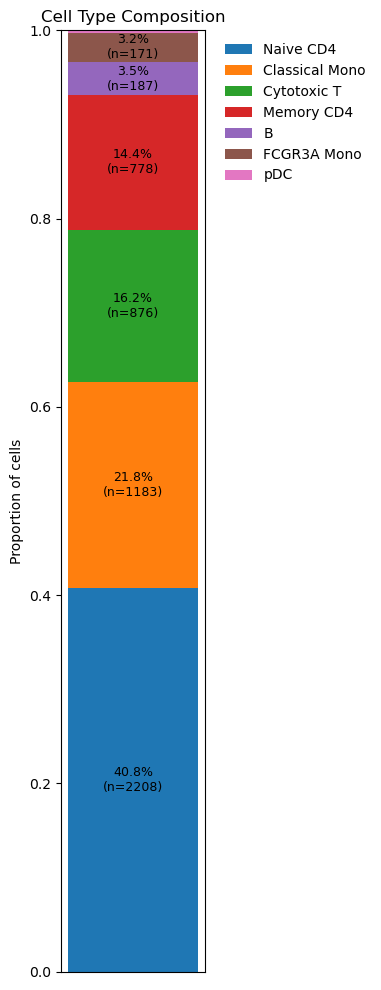

In [57]:
# Single 100% stacked bar showing composition; annotate % and n (hide n if <3%).

counts = adata_ok.obs["cell_type"].value_counts()
total = counts.sum()
proportions = counts / total

fig, ax = plt.subplots(figsize=(4, 10))

bottom = 0

for cell_type, count in counts.items():
    prop = count / total
    
    # Draw stacked bar segment
    ax.bar(
        x=0,
        height=prop,
        bottom=bottom,
        width=0.6,
        label=cell_type
    )
    
    # Only annotate if ≥ 3%
    if prop >= 0.03:
        ax.text(
            0,
            bottom + prop / 2,
            f"{prop*100:.1f}%\n(n={count})",
            ha="center",
            va="center",
            fontsize=9
        )
    
    bottom += prop

# Formatting
ax.set_ylim(0, 1)
ax.set_xticks([])
ax.set_ylabel("Proportion of cells")
ax.set_title("Cell Type Composition")

ax.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False
)

plt.tight_layout()
plt.show()

## 12. Exploratory differential expression (cell-type markers)

In [58]:
# Exploratory DGE: rank genes per cell type (cell-level Wilcoxon).

sc.tl.rank_genes_groups(
    adata_ok,
    groupby="cell_type",
    method="wilcoxon",
    layer='l1p',
    pts=True,
)

# sc.pl.rank_genes_groups(adata_ok, n_genes=10, sharey=False)

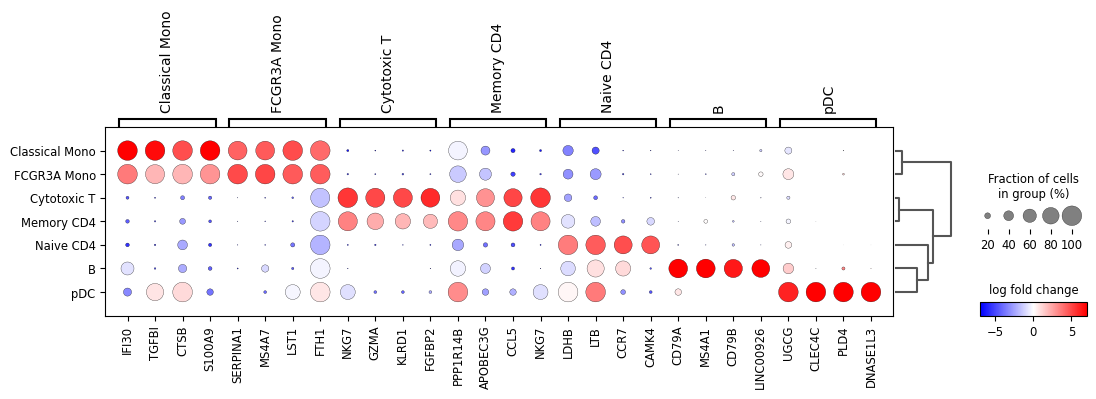

In [59]:
# Dotplot of top DE genes (log fold-changes) for quick inspection.

sc.pl.rank_genes_groups_dotplot(adata_ok, n_genes=4, values_to_plot= 'logfoldchanges', min_logfoldchange=3, vmax=7, vmin=-7, cmap='bwr')

In [60]:
# Extract DE table for a selected group (example: NK cell).

dedf = sc.get.rank_genes_groups_df(adata_ok, group="B")
dedf

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,CD79A,21.876276,9.371236,4.371171e-106,1.069608e-101,0.941176,0.013387
1,MS4A1,21.863020,8.799299,5.844695e-106,1.069608e-101,0.941176,0.022375
2,CD79B,20.848152,6.301282,1.584205e-96,1.932783e-92,0.909091,0.061388
3,LINC00926,20.400978,7.589226,1.639058e-92,9.998526e-89,0.882353,0.022566
4,BANK1,20.261946,10.085685,2.787240e-91,1.457368e-87,0.871658,0.005928
...,...,...,...,...,...,...,...
36596,CALM1,-17.002920,-1.524132,7.812818e-65,1.243291e-61,0.860963,0.988334
36597,AAK1,-19.702774,-5.474047,2.041203e-86,6.791825e-83,0.064171,0.873590
36598,GIMAP7,-19.833309,-7.764176,1.535919e-87,6.246240e-84,0.021390,0.859820
36599,ITM2B,-20.462307,-1.950598,4.667708e-93,3.416855e-89,0.893048,0.997896
